# Diffraction

Being able to visualize and manipulate concepts in real time is a very powerful tool for gaining intuition about a concept or system you're working with. Throughout this assignment, we will use Python to create interactive plots for just this purpose.

In the previous laboratory, we studied the behavior of waves under spatial boundary conditions and observed that confinement leads to structured interference patterns. In this experiment, we extend these ideas by studying diffraction as a consequence of spatial confinement and interference. We begin with light passing through a finite aperture (single-slit diffraction), where restricting a wave in space produces a continuous angular distribution. We then consider interference from two localized sources (double-slit diffraction), where discrete angular fringes emerge from phase matching. Finally, we examine the limiting case of many regularly spaced scattering centers: a crystalline lattice.

At each stage, the same physical principle applies: waves originating from different points accumulate relative phase, and only certain angular configurations satisfy the condition for constructive interference. Increasing geometric structure sharpens these interference conditions, progressing from broad diffraction envelopes (single slit), to discrete fringes (double slit), and ultimately to sharp diffraction peaks produced by periodic atomic planes.

---

**Chemistry Learning Objectives:**
- C2.1: Explain diffraction as a consequence of wave interference in a variety of physical systems. 
- C2.2: Understand the map between real-space structure and angular structure and the physical origin of Bragg's law.
- C2.3: Relate powder XRD spectral features - diffraction angles and systematic absences - to crystal structure. 

**Programming Learning Objectives:**
- P2.1: Write arithmetic expressions as reusable Python functions.
- P2.2: Use for loops and logic to process data.
- P2.3: Use basic `pandas` for loading and processing tabular data.
- P2.4: Construct reusable data analysis workflows by generalizing code used for a specific task as a function.
---

**Table of Contents**
- [Part 1 - Single-Slit Diffraction](#Part-1---Single-Slit-Diffraction) `40 points`
- [Part 2 - Phase Differences and Angular Interference](#Part-2---Phase-Differences-and-Angular-Interference) `40 points`
- [Part 3 - The Crystal Lattice and Mirror Planes](#Part-3---The-Crystal-Lattice-and-Mirror-Planes) `50 points`
- [Part 4 - Powder Diffraction and Interpreting XRD Spectra](#Part-4---Powder-Diffraction-and-Interpreting-XRD-Spectra) `40 points`
- [Reflection](#Reflection) `10 points`

`Total: 180 points`

<br></br>

## Part 1 - Single-Slit Diffraction

In the previous laboratory, standing waves arose because a finite spatial domain imposed boundary conditions on a wave. Only certain phase relationships were compatible with those boundaries, leading to discrete allowed modes.

Diffraction from a single slit is governed by the same idea. Instead of confinement along a string, we now have confinement in a transverse spatial direction. Light passing through a narrow aperture spreads out, and the angular distribution of intensity is determined by interference between contributions from different points across the slit.

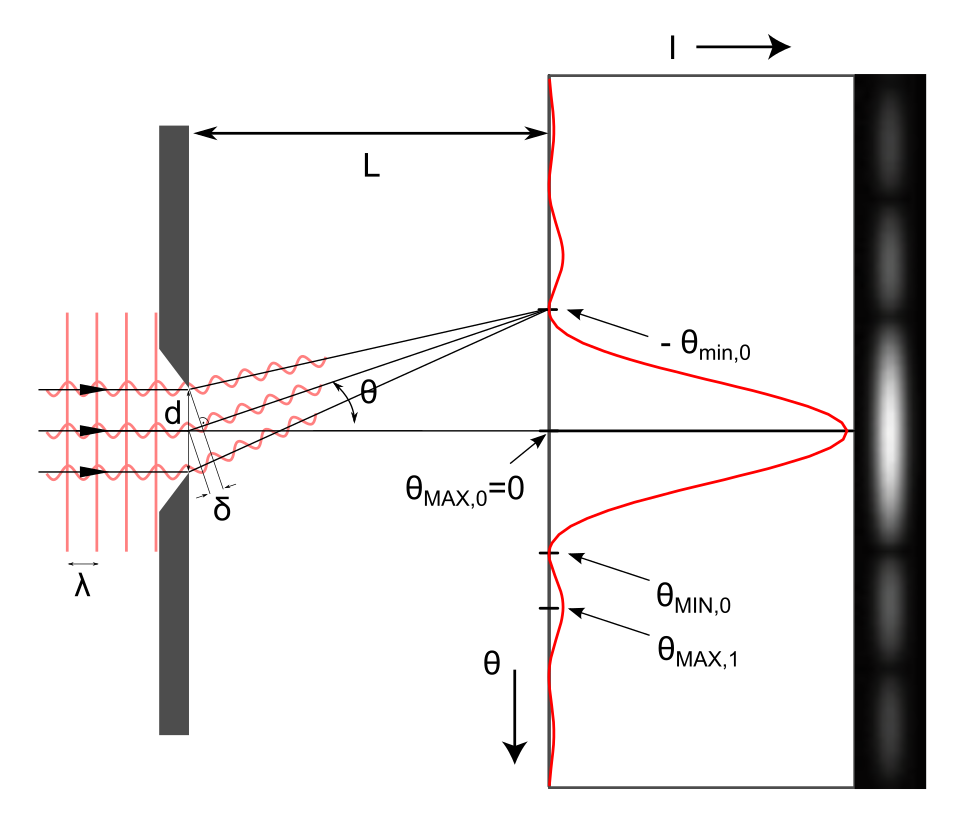

(image credit: https://commons.wikimedia.org/wiki/File:Single_Slit_Diffraction.svg)

Unlike the crystal lattice case (which we will study later), a single slit does not impose periodic structure. Instead, it imposes a finite spatial extent. This produces a continuous diffraction envelope whose shape reflects the width of the aperture.

Consider a slit of width $a$, illuminated by monochromatic light of wavelength $\lambda$. In the far-field (Fraunhofer) limit, the intensity as a function of observation angle $\theta$ is
$$
I (\theta) \propto \left( \frac{\sin \beta}{\beta} \right)^2, \quad \beta = \frac{\pi a}{\lambda} \sin \theta
$$
This result can be derived by summing (integrating) the phase contributions from each point across the slit. The key features are:

 - The pattern has a central maximum at $\theta = 0$.
 - Intensity minima occur when
    $$
    a \sin \theta = m \lambda, \quad m = \pm 1, \pm 2, \dots
    $$
 - Increasing the slit width $a$ narrows the angular distribution.
 - Decreasing the wavelength \(\lambda\) also narrows the angular distribution.

Conceptually, this is the diffraction analogue of standing waves: restricting a wave in space necessarily spreads it in angle. This tradeoff between spatial confinement and angular (or momentum) spread will reappear later when we discuss crystals and peak broadening.

In this section, you will implement this model computationally and explore how the diffraction pattern depends on slit width and wavelength.

---
### A Quick Primer on Python Functions

We gained some experience writing one-shot arithmetical expressions in the previous lab. This week, we will use arithmetic to write reusable **functions**. Functions in Python are defined as follows:
```python
def function_name(input_1, input_2):
    """
    A short description of what this function does.
    """
    # do some computation with the inputs
    output = input_1 + input_2
    return output 
```
An example function, `beta()`, is provided in Coding Activity 1 with commentary on each of its components.

---

### Coding Activity 1
`30 points`

- P2.1: Write simple Python functions to model single-slit, double-slit, and lattice-based angular interference
- P2.3: Construct small modular programs that separate physical models from visualization and analysis

Write simple Python functions to evaluate the single-slit diffraction intensity and visualize how spatial confinement controls angular structure. You will use these functions repeatedly later, so focus on clarity and reusability.


#### Part A - Implement the Diffraction Model

**Your Task:**

Write a function that computes
$$
\beta (\theta; a, \lambda) = \frac{\pi a}{\lambda} \sin \theta
$$
and a second function that evaluates
$$
I(\theta) = \left( \frac{\sin \beta}{\beta} \right)^2.
$$

Your function should:
 - accept theta in radians (scalar or NumPy array),
 - take slit width a and wavelength as parameters,
 - return a dimensionless intensity.

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Part A: Single-slit model
# ------------------------------------------------------------

def beta(theta, a, wavelength): # function definition. 'def' lets Python know you're defining a function
    # def, name of function, parameters in parenthesis, followed by a colon
    # code that "belongs" to a function must be indented - this is how Python handles scoping
    # below is the "docstring" - this is an optional comment explaining how the function works
    """
    Computes the dimensionless phase parameter for single-slit diffraction:
    beta(theta; a, lam) = (pi * a / lam) * sin(theta)

    Parameters
    theta: (array) Observation angle in radians.
    a : (number) Slit width.
    wavelength : (number) Wavelength (same units as a).

    Returns
    beta_val : (array) Dimensionless phase parameter.
    """
    beta_val = np.pi * a / wavelength * np.sin(theta)
    return beta_val # most important part - this makes sure your function outputs a value
    # function will return "none" without this and will be useless to us.

# example of defining a variable using the output of a function:
test_beta_val = beta(1,1,1)
print(test_beta_val)

2.643559064081456


In [53]:

# ===== YOUR TURN =====
# Complete the function below, using beta() as an example. 
# Hint: use np.sin() for the sine function.

def single_slit_intensity(theta, a, wavelength):
    """
    Computes single-slit diffraction intensity:
    I(theta) = (sin(beta) / beta)^2

    Parameters
    theta : (array) Observation angle in radians.
    a : (number) Slit width.
    wavelength : (number) Wavelength.

    Returns
    I : (array) Dimensionless intensity.
    """
    # be careful not to overwrite function names with variable names!
    
    # Step 1: call beta() to get beta_val
    beta_val = beta(theta, a, wavelength)
    # Step 2: compute I using np.sinc (which computes sin(pi*x)/(pi*x))
    I = np.sinc(beta_val / np.pi) ** 2
    # Step 3: return I
    return I


#### Part B - Visualize the Diffraction Pattern

1. Create an angular grid over a small range (for example $ \theta \in [-\pi / 6, \pi / 6 ]$). An example is given below.
2. Plot $I(\theta)$ for a reasonable choice of $a$ and $\lambda$. Plots should have a main title as well as axis titles. Use formatted strings such as `r'$\lambda$'` for math expressions.
3. Vary $a$ while holding $\lambda$ fixed. Generate new plots and observe how the pattern changes.
4. Vary $\lambda$ while holding $a$ fixed. Generate new plots and observe how the pattern changes.

**Creating an angular grid:**  
Use `np.linspace(start, stop, num_points)` to create an evenly spaced array of angles. For example:
```python
theta = np.linspace(-np.pi/6, np.pi/6, 500)
```
This creates 500 evenly spaced values from $-\pi/6$ to $\pi/6$. Use `np.pi` for the constant $\pi$ — do **not** type a decimal approximation like 3.14.

Text(0, 0.5, '$I(\\theta)$')

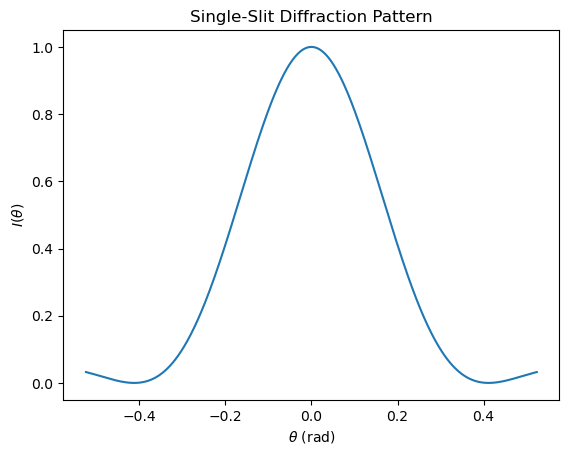

In [54]:

# ------------------------------------------------------------
# Part B: Visualization
# ------------------------------------------------------------


# Step 1: Create an angular grid
theta = np.linspace(-np.pi/6, np.pi/6, 500)

# Step 2: Choose values for slit width (a) and wavelength
a = 2.5
wavelength = 1

# Step 3: Call your single_slit_intensity function
I = single_slit_intensity(theta, a, wavelength)

# Step 4: Plot I vs theta with appropriate labels
plt.plot(theta, I)
plt.title('Single-Slit Diffraction Pattern')
plt.xlabel(r'$\theta$ (rad)')
plt.ylabel(r'$I(\theta)$')


#### Part C - Locate Diffraction Minima

Using your intensity function, numerically identify the first few angles at which the intensity goes to (or near) zero. and compare these values to the theoretical condition
$$
a \sin \theta =m \lambda.
$$

**Your Task:**
- Leave comments describing what each line of code is doing. 
- fill in the missing definition of $a \sin \theta$ in the second for loop.
- fill in the missing conditional in the second for loop.

In [55]:

# ------------------------------------------------------------
# Part C: Locate diffraction minima
# ------------------------------------------------------------

# Step 1: Find angles where I is very small

# enumerate lets you loop with both index and value
# we can access specific positions in a list by index like `list[index]`

# LEAVE COMMENTS EXPLAINING WHAT'S HAPPENING HERE!
list_0_I_theta = []
for i, I_val in enumerate(I):
    if I_val < 0.00001:
        print(f"Near-zero at theta = {theta[i]:.4f} rad")
        list_0_I_theta.append(theta[i]) 

# Step 2: Compare a*sin(theta_min) to m*lambda

for theta in list_0_I_theta:
    m = 1 # If you see one minimum on each side of peak, then m = +/- 1
    m_lambda = m * wavelength
    # for each theta value, calculate absolute value of a * sin(theta) since m = `+/-` 1
    # use np.abs() for absolute value
    a_sin_theta = np.abs(a * np.sin(theta))
   
    threshold = 0.01
    # check that absolute value of difference between these is below the threshold
    if np.abs(a_sin_theta - m_lambda) < threshold:
        print("relationship holds!")
        print(f"m * lambda: {m_lambda}")
        print(f"a * sin(theta): {a_sin_theta}")
    else:
        print("relationship doesn't hold!")
        print(f"m * lambda: {m_lambda}")
        print(f"a * sin(theta): {a_sin_theta}")


Near-zero at theta = -0.4124 rad
Near-zero at theta = -0.4103 rad
Near-zero at theta = 0.4103 rad
Near-zero at theta = 0.4124 rad
relationship holds!
m * lambda: 1
a * sin(theta): 1.001962208778171
relationship holds!
m * lambda: 1
a * sin(theta): 0.9971533262259356
relationship holds!
m * lambda: 1
a * sin(theta): 0.9971533262259356
relationship holds!
m * lambda: 1
a * sin(theta): 1.001962208778171


### Question 1
`10 points`

- C2.1: Explain diffraction as a consequence of wave interference under geometric constraints
- C2.3: Interpret diffraction features in terms of spatial confinement

a) Explain why narrowing the slit causes the diffraction pattern to spread out in angle.
b) In what sense is the slit width $a$ playing the same conceptual role as the length $L$ in a standing wave problem?

---

*Your answer here (`double click me!`):*

a) Narrowing the slit causes the diffraction pattern to spread out in angle because the narrower an aperature is in relation to the wavelength, the more light spreads out after travelling through it. 

b) the length L in the standing wave problem determines the interference pattern observed for the allowed modes; same thing here.

<br></br>

## Part 2 - Phase Differences and Angular Interference

### 2.1 The Double Slit Experiment
In Section 2, diffraction arose from continuous spatial confinement: restricting a wave to pass through a finite aperture produced a broadened angular distribution. We now introduce a second slit. This produces a qualitatively new feature: discrete angular fringes. These fringes arise because waves traveling along different paths accumulate different phases.

Consider two identical slits separated by a distance $d$. Light emerging from each slit travels a different distance to reach a point on the screen at angle $\theta$. The resulting path difference is

$$
\Delta(\theta) = d \sin \theta.
$$

A path difference $\Delta$ corresponds to a phase difference

$$
\Delta \phi(\theta)
=
\frac{2\pi}{\lambda}\,\Delta(\theta)
=
\frac{2\pi}{\lambda} d \sin \theta.
$$

The electric fields from the two slits combine linearly, but the observed brightness depends on intensity, which is proportional to the square of the total amplitude:

$$
I \propto A^2.
$$

As a result, the relative phase between the two contributions determines whether they interfere constructively or destructively.

Constructive interference occurs when the two waves are in phase:

$$
\Delta \phi = 2\pi n,
$$

which gives

$$
d \sin \theta = n \lambda.
$$

Destructive interference occurs when the waves are out of phase by $\pi$:

$$
\Delta \phi = (2n+1)\pi,
$$

leading to

$$
d \sin \theta = \left(n + \frac12\right)\lambda.
$$

Thus the angular fringe pattern is a direct consequence of phase matching between the two paths.

Run the interactive cell below to explore how slit separation and wavelength control the angular interference pattern.

In [56]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

from xrd_helper import interactive_double_slit_plot
interactive_double_slit_plot()

interactive(children=(FloatSlider(value=0.0, description='theta', max=90.0, min=-90.0), Output()), _dom_classe…

### 2.2 Periodicity

The double slit represents the simplest configuration in which discrete angular structure emerges from interference. What happens if we continue this process and increase the number of equally spaced scatterers?

As more sources are added,

- the maxima become sharper,  
- off-peak angles are increasingly suppressed,  
- and the interference pattern approaches a set of narrow angular peaks.

At this point, we will perform a demonstration using many equally spaced slits to illustrate how increasing the number of sources transforms broad interference fringes into sharp angular maxima.

As you observe the pattern, pay attention to the following:

- how the main peaks become narrower as more slits are added,  
- how intensity between peaks decreases,  
- and how only specific angles remain strongly allowed.

This demonstration provides a macroscopic analogue of what occurs in a crystal lattice.

In [57]:
from xrd_helper import interactive_diffraction_plot
interactive_diffraction_plot()

interactive(children=(FloatSlider(value=0.0, description='theta', max=70.0, min=-70.0), Output()), _dom_classe…

### 2.3 Two Scatterers in a Crystal

In the limit of a very large number of regularly spaced scatterers, the system becomes effectively periodic. At that point, only specific angles satisfy the phase-matching condition, and diffraction consists of sharp reflections rather than broad fringes.

A crystal lattice is precisely such a system: an enormous periodic array of atoms. X-ray diffraction is therefore the many-slit limit of the double-slit experiment.

In the previous demonstration, you observed how a large number of equally spaced mirrors produces sharp angular maxima, while suppressing intensity at most other angles. This behavior arose purely from periodic geometry and phase matching.

We now zoom in to atomic length scales.

A crystal lattice may be viewed as an array of localized scattering centers (atoms). Although real crystals contain an enormous number of atoms, the essential physics can already be seen by considering the simplest crystalline analogue of the double slit: diffraction from two atoms separated by a fixed distance.

Run the interactive below, which displays the diffraction pattern produced by two points on a crystal lattice.

In [58]:
from xrd_helper import interactive_reflection_plot
interactive_reflection_plot()

interactive(children=(FloatSlider(value=0.0, description='x2', max=1.0, min=-1.0, step=0.01), FloatSlider(valu…

Although the physical interpretation is different, the mathematics is identical to the double-slit case. The separation $d$ now represents an interatomic spacing rather than a macroscopic slit separation, but the interference condition is unchanged.

The path difference between rays scattered from the two atoms is

$$
\Delta (\theta) = 2d \sin \theta 
$$

which produces a phase difference
$$
\Delta \phi(\theta) = \frac{4 \pi}{\lambda} d \sin \theta.
$$

Constructive interference therefore occurs when

$$
\Delta \phi = 2 \pi n,
$$

or equivalently,

$$
2d \sin \theta = n \lambda.
$$

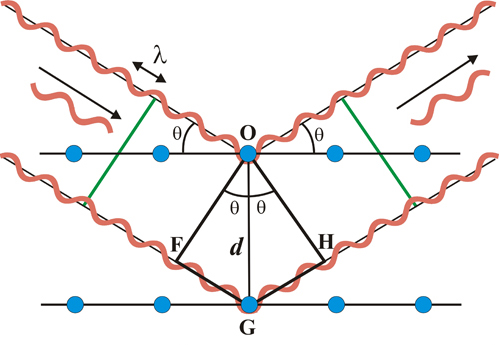

(image source: https://www.xtal.iqf.csic.es/Cristalografia/parte_05_5-en.html)

This demonstrates a key idea: diffraction from atoms follows exactly the same wave-interference rules as diffraction from slits. The difference lies only in scale. In both cases, discrete angular structure arises from phase matching between waves traveling along different paths.

Here, the sources are atoms rather than apertures. Nevertheless, the observed pattern is governed by the same geometric and phase relationships.

### Coding Activity 2
`30 points`

- P2.1: Write simple Python functions to model single-slit, double-slit, and lattice-based angular interference
- P2.3: Construct small modular programs that separate physical models from visualization and analysis

In this challenge, you will construct a minimal two-scatterer interference model and verify that discrete angular maxima arise directly from phase matching. This model will serve as a bridge between the optical double-slit experiment and atomic-scale diffraction.

Your goal is not to reproduce experimental data, but to translate the phase-difference equations derived in this section into a simple computational model.

---

#### Part A - Path Difference and Phase Difference

Write a function that computes the path difference

$$
\Delta(\theta; d) = d \sin \theta .
$$

Then write a second function that converts this into a phase difference:

$$
\Delta\phi(\theta; d,\lambda) = \frac{2\pi}{\lambda} d \sin \theta .
$$

Your functions should accept $\theta$ in radians and work for both scalar and NumPy array inputs.

---

**Your Task:**

Implement the following functions. A skeleton is provided for the first; you will need to define the second from scratch.
1. A function computing $\Delta(\theta;d)$.
2. A function computing $\Delta\phi(\theta;d,\lambda)$.

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Part A: Path difference and phase difference
# ------------------------------------------------------------

# be careful not to overwrite function names with variable names!

# implement a function, path_difference, which accepts theta and d as arguments and returns a path difference in
# arbitrary units (same as d). 
def path_difference(theta, d):
    delta = d * np.sin(theta)
    return delta

## YOUR TURN: define a function, phase_difference, which accepts theta, d, wavelength as arguments and 
# returns a phase difference in radians.
# your function should call path_difference.
# hint - you can use np.pi for pi. 

# define phase_difference function here
def phase_difference(theta,d,wavelength):
    delta = path_difference(theta,d)
    phase_val = 2 * np.pi / wavelength * delta
    return phase_val


#### Part B - Two-Scatterer Intensity Model

Using your phase function, construct a minimal interference intensity model:

$
I(\theta;d,\lambda) = \cos^2\!\left(\frac{\Delta\phi(\theta;d,\lambda)}{2}\right).
$

This expression is chosen because it is nonnegative, periodic in phase, and has maxima when $\Delta\phi = 2\pi n$.

Write a function that evaluates $I(\theta)$.

3. A function computing $I(\theta)$.

In [60]:

# ------------------------------------------------------------
# Part B: Minimal two-scatterer intensity model
# ------------------------------------------------------------

# define the function and its parameters
    # compute delta_phi using the phase_difference() function you defined above
    # take cos and square
    # return intensity value
    
def two_scatterer_intensity(theta,d,wavelength):
    phi = phase_difference(theta,d,wavelength)
    I = np.cos(phi / 2)**2
    return I 
    
# be careful not to overwrite function names with variable names!

#### Part C - Visualizing Angular Fringes

1. Create an angular grid over a small range (for example $\theta \in [-\pi/6,\pi/6]$).
2. Choose physically reasonable values for $d$ and $\lambda$ and plot $I(\theta)$.
3. Explore how the plot changes as you change $\lambda$ and $d$.
4. Try to find at least one plot showing angular interference fringes.

Text(0, 0.5, 'I')

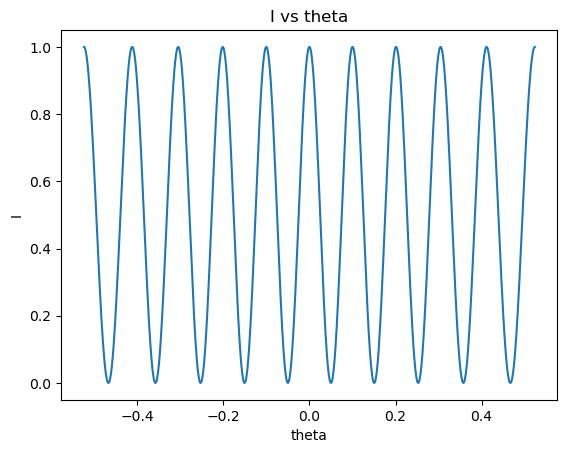

In [61]:
# ------------------------------------------------------------
# Part C: Plotting (students should experiment)
# ------------------------------------------------------------

# Create an angular grid using np.linspace(min,max,num_points), choose d and wavelength, then plot.
# (Refer to the angle-grid example in Part 1B if needed.)
# TODO: create theta array, choose d and wavelength
theta = np.linspace(-np.pi/6,np.pi/6,1000)
d = 1
wavelength = 0.1
# TODO: call two_scatterer_intensity(theta, d, wavelength) to create I array
I = two_scatterer_intensity(theta,d,wavelength)
# TODO: plot I vs theta with labels
plt.plot(theta,I)
plt.title("I vs theta")
plt.xlabel("theta")
plt.ylabel("I")

### Question 2
`10 points`

- C2.1: Explain diffraction as a consequence of wave interference in a variety of physical systems  

a) Compare the single-slit pattern from Section 1 with the two-scatterer pattern in this section. How does the pattern change when a second source is introduced?

b) When we went from two slits to many in diffraction, what happened? 

c) What do you expect to happen as we go from two scatterers to a roughly infinite number of equally spaced scatterers, as in a crystal lattice?

d) Bragg's law is often presented as a formula to memorize. Based on this section, explain why it is better understood as a phase-matching condition.

---

a) When a second source is introduced, the pattern has large regions of constructive interference which keep a high intensity farther away from x = 0.

b) as we approached the limit of infinite slits, the peaks became sharper and sharper and more uniform.

c) likewise, for a crystal lattice it would look a lot like this but would get sharper and sharper.

d) Bragg's law actually comes from the phases of light reflecting off the points in a crystal, it's not arbitrary. it's a result of constructive and destructive interference.

<br></br>

## Part 3 - The Crystal Lattice and Mirror Planes

In the previous section, we derived Bragg's law as a phase-matching condition for waves scattered from parallel atomic planes. To use diffraction as a structural tool, we now need to describe what a "crystal" is and how to label the families of planes that can produce reflections.

Even though a crystal may contain an enormous number of atoms, its structure can be described efficiently using **symmetry**.

---

### 3.1 The Crystal Lattice

At minimum, a three-dimensional crystal exhibits **translational symmetry** in three independent directions. This means there exist three vectors such that translating the lattice by any integer combination of them produces the same structure. If these vectors are written as $\vec{a}, \vec{b}, \vec{c}$, then any lattice point can be reached by

$$
\vec{R} = u\vec{a} + v\vec{b} + w\vec{c},
$$

where $u,v,w$ are integers.

Because of this symmetry, we can describe the infinite crystal by specifying the region enclosed by $\vec{a},\vec{b},\vec{c}$. This region is called the **unit cell**.

Crystal structures are defined by **cell parameters**, which describe the magnitudes and relative angles of these translation vectors. The magnitudes are denoted $a,b,c$ and the angles between them are denoted $\alpha,\beta,\gamma$.

Using these parameters, three-dimensional crystals are classified into **seven crystal systems** and **14 Bravais lattices**.

Crystals can also exist in two dimensions, where only three parameters are needed: $a,b,\gamma$. In this lab, we begin with two-dimensional lattices because they make symmetry and geometry easy to visualize. The goal is not to master crystallography in full generality, but to build geometric intuition for periodic structure before returning to diffraction and plane spacings.

### Coding Activity 3A
`20 points`

- P2.1: Write simple Python functions to model lattice-based angular interference
- C2.3: Interpret diffraction features in terms of periodicity, connecting angular structure to real-space geometry

#### Exploring 2D Bravais Lattices

1. Run the interactive tool below to explore how changing the lattice parameters of a 2D crystal changes the resulting structure.
2. Use the function `two_d_crystal_lattice()` to create examples of all four primitive two-dimensional Bravais lattices and title them accordingly. Your solution should call this function 4 times to display 4 different outputs.
   
Suggested lattice types to demonstrate:
 - oblique (primitive)
 - rectangular (primitive)
 - square
 - hexagonal
 
Use the [reference table in Wikipedia](https://en.wikipedia.org/wiki/Bravais_lattice#In_2_dimensions) if needed.

In [62]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

from xrd_helper import interactive_crystal_plot
interactive_crystal_plot()

interactive(children=(FloatSlider(value=1.0, description='a', max=2.0, min=1.0), FloatSlider(value=1.5, descri…

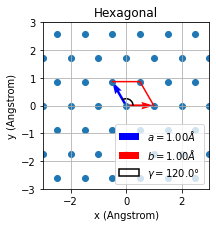

In [ ]:
from xrd_helper import two_d_crystal_lattice

# Call two_d_crystal_lattice(length_1, length_2, angle, title='Title')
# to show and label the four primitive 2D Bravais lattices.

two_d_crystal_lattice(1.0, 1.5, 75, title='Oblique')


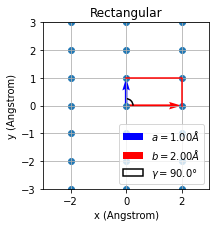

In [76]:

two_d_crystal_lattice(1.0, 2.0, 90, title='Rectangular')


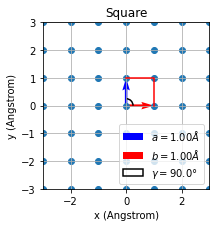

In [77]:

two_d_crystal_lattice(1.0, 1.0, 90, title='Square')


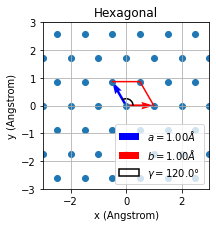

In [78]:

two_d_crystal_lattice(1.0, 1.0, 120, title='Hexagonal')


### 3.2 Mirror Planes and HKL Indices

Diffraction is not limited to light reflecting from atoms arranged along a line. It occurs for any family of parallel planes that intersect a periodic arrangement of atoms, provided the plane spacing $d$ is large enough that Bragg's condition has a nonzero solution.

In this context, these families of planes are often called mirror planes. To label them, we use the Miller indices $h,k.l$.

A Miller-indexed plane is defined by its intercepts with the crystal axes. If a plane intersects the $x$-, $y$-, and $z$-axes at distances \(b_x, b_y, b_z\) (measured in units of the lattice constants), then the Miller indices are proportional to the reciprocals:

$$
h \propto \frac{1}{b_x}, k \propto \frac{1}{b_y}, l \propto \frac{1}{b_z}.
$$

After taking reciprocals, we clear fractions to obtain integers. If a plane does not intercept an axis, the intercept is treated as infinity and the corresponding index is $0$, consistent with $1/infty = 0$.

For a cubic lattice system, the spacing between adjacent planes with indices 

$$
d_{hkl} = \frac{a}{\sqrt{h^2 + k^2 + l^2}}
$$

where $a$ is the unit cell length in the 
$x$, $y$, and $z$ directions.

Combining this with Bragg's law explains why diffraction patterns contain peaks associated with different integer triples $(h, k, l)$: each family of planes corresponds to a characteristic spacing, and therefore to characteristic diffraction angles.

### Coding Activity 3B
`20 points`

- P2.1: Write simple Python functions to model lattice-based angular interference
- C2.3: Interpret diffraction features in terms of periodicity, connecting angular structure to real-space geometry

#### Exploring Mirror Planes

Run the interactive tool below to explore how changing the Miller indices affects the planes you obtain and the distances between them.

As you explore, pay attention to how increasing $h^2 + k^2 + l^2$ changes the density of planes and the spacing. This relationship will become central when we interpret peak positions in powder XRD patterns.

In [64]:
import matplotlib.pyplot as plt

from xrd_helper import interactive_mirror_plot
interactive_mirror_plot()  

interactive(children=(IntSlider(value=0, description='h', max=2, min=-2), IntSlider(value=0, description='k', …

### Question 3
`10 points`

- C2.1: Explain diffraction as a consequence of wave interference under geometric constraints
- C2.3: Interpret diffraction features in terms of spatial confinement, periodicity, and finite domain size

a) Explain why translational symmetry allows a crystal to be described using a unit cell.

b) In two dimensions, why are only three parameters $a, b, \gamma$ needed to specify a primitive lattice?

c) Real world crystals are not actually infinite. Does this matter? Why or why not? 

d) Explain how the interactive mirror-plane plots demonstrate that the same unit cell can support many different mirror planes.

---

a) Because a crystal has translational symmetry, the unit cell is enough to uniquely specify all information about the structure of the crystal. This is because to generate the infinite structure we can just tile space with our unit cell.

b) in two dimensions, there is only the length of the translation vectors and the angle between them to consider. 

c) this does not practically matter. real world crystals are so large that they effectively meet the infinite limit. a mole is a big number.

d) some of the planes did not actually have atoms lined up on top of one another. Yet they still behave as mirror planes. The same periodic lattice will have many mirror planes.

<br></br>

## Part 4 - Powder Diffraction and Interpreting XRD Spectra

Up to this point, we have focused on diffraction from specific sets of mirror planes in a single crystal. In that setting, the observed diffraction pattern depends on the orientation of the crystal relative to the incident X-ray beam: rotating the crystal changes which planes satisfy the Bragg condition.

In practice, many experiments instead use powder X-ray diffraction. A powder sample consists of a very large number of tiny crystallites, each randomly oriented in space. When an X-ray beam passes through such a sample, every possible crystal orientation is present simultaneously.

As a result, for any family of mirror planes that satisfies Bragg's law,

$$
2 d \sin \theta = n \lambda,
$$

there will always be some crystallites oriented at exactly the required angle. Rather than producing isolated spots (as in single-crystal diffraction), each allowed reflection generates a cone of scattered intensity. On a detector, these cones appear as concentric rings. The radius of each ring corresponds to a specific scattering angle $2\theta$.

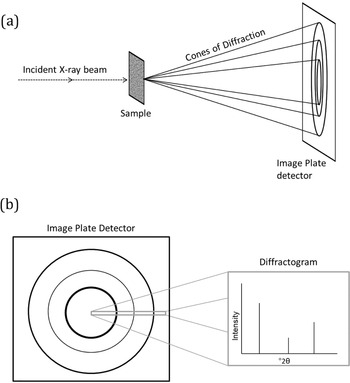

(image credit: https://www.cambridge.org/core/books/analytical-geomicrobiology/xray-diffraction-techniques/5527D02F25F05424B5974BD9E0FCB229)

Thus, a powder XRD pattern is an orientation-averaged fingerprint of the crystal: each peak corresponds to a particular interplanar spacing $d$, and therefore to a particular family of $(hkl)$ planes.

Earlier, we examined mirror planes in cubic lattices and computed their associated spacings using

$$
d_{hkl} = \frac{a}{\sqrt{h^2 + k^2 + l^2}},
$$

together with Bragg's law to predict peak positions. In a powder experiment, all such allowed planes contribute simultaneously, producing a one-dimensional spectrum of intensity versus $2\theta$.

You might therefore expect that every possible combination of $h$, $k$, and $l$ would generate a peak. However, real crystals possess additional symmetry. These symmetries impose selection rules that cause certain reflections to vanish identically. These missing peaks are called systematic absences (or characteristic absences), and they provide direct information about the underlying lattice type.

For common cubic lattices:
 - Simple cubic: Peaks appear for all integer combinations of $h$, $k$, and $l$.
 - Face-centered cubic (FCC): Peaks appear only when $h$, $k$, and $l$ are either all even or all odd.
 - Body-centered cubic (BCC): Peaks appear only when $h + k + l$ is even.

These rules arise from destructive interference between symmetry-related atoms within the unit cell. Physically, they reflect additional phase cancellations imposed by the lattice geometry.

By indexing the observed powder peaks with $(hkl)$ values and applying these selection rules, we can determine:

1. the lattice parameter $a$,
2. the crystal system (e.g., simple cubic, FCC, or BCC),
3. which reflections are allowed or forbidden by symmetry.

In other words, the powder XRD spectrum encodes both geometric information (interplanar spacings) and symmetry information (systematic absences).

### Coding Activity 4
`30 points`

- P2.2: Implement basic data-analysis workflows (peak identification and regression) using structured, reusable code
- P2.3: Construct small modular programs that separate physical models from visualization and analysis
- C2.2: Use powder XRD data to determine lattice spacings and relate extracted structural parameters to underlying crystal structures

#### Processing Powder XRD Spectra

In this section, you will analyze several powder XRD datasets and automate the interpretation process.

Ensure you have the following files in an `xrd_jupyter_data` directory, in the same directory as this notebook:
 - `AuB2.xy`
 - `AgB2.xy`
 - `NbTa.xy`
 - `Po.xy`

Each file contains two columns: scattering angle ($2\theta$) and intensity.



### Part A
For $\text{AgB}_2$, use the provided starter code to:
- load the spectrum
- identify peak positions
- assign candidate $(hkl)$ indices,
- compute the lattice parameter $a$,
- and determine the crystal type using the selection rules above.

To support this analysis, we will use the `pandas.DataFrame` object. A `DataFrame` is similar to a spreadsheet: it organizes data into labeled columns and rows. You can load a file into a `DataFrame` using `pd.read_csv()`. Individual columns can be accessed using the subscript operator (square brackets), and new columns can be created in the same way.

**Your Task:**
Execute each cell, and add comments explaining what the code is doing. Text following a hash `#` is considered a comment by Python.

In [65]:
import pandas as pd
import numpy as np
from xrd_helper import plot_spectrum
from xrd_helper import pick_peaks
from xrd_helper import calculate_distances
from xrd_helper import index_hkl
from xrd_helper import classify_cubic_spectra

#AgB2
wavelength = 1.54 #1.54 angstrom wavelength x-rays used for all these
spectrum = pd.read_csv('xrd_jupyter_data/AgB2.xy',sep=r'\s+',header=None,names=['2theta','intensity','_'])
spectrum #typing a variable by itself in the last line of a block will show its contents

,2theta,intensity,_
0,1.00,0.00000,0.0
1,1.01,0.44387,0.0
2,1.02,0.43533,0.0
3,1.03,0.42703,0.0
4,1.04,0.41898,0.0
...,...,...,...
11895,119.95,0.03020,0.0
11896,119.96,0.03003,0.0
11897,119.97,0.02987,0.0
11898,119.98,0.02970,0.0


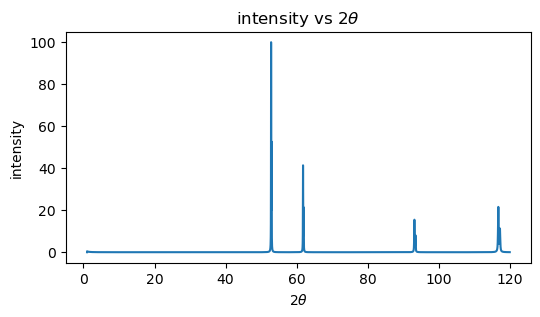

(<Figure size 600x300 with 1 Axes>,
 <Axes: title={'center': 'intensity vs $2\\theta$'}, xlabel='$2\\theta$', ylabel='intensity'>)

In [66]:

plot_spectrum(spectrum['2theta'],spectrum['intensity'])

In [67]:
peaks = pick_peaks(spectrum['2theta'],spectrum['intensity'])
peaks

,2theta,intensity
0,52.81,100.00000
1,61.80,41.38197
2,93.14,15.48053
3,93.44,8.11418
4,116.77,21.58009


In [68]:
peaks['d'] = calculate_distances(peaks['2theta'],wavelength)
peaks

,2theta,intensity,d
0,52.81,100.00000,1.731452
1,61.80,41.38197,1.499393
2,93.14,15.48053,1.060292
3,93.44,8.11418,1.057675
4,116.77,21.58009,0.904191


In [69]:
peaks['hkl'], cell_param_a = index_hkl(peaks['d'],0)
peaks

,2theta,intensity,d,hkl
0,52.81,100.00000,1.731452,111
1,61.80,41.38197,1.499393,200
2,93.14,15.48053,1.060292,220
3,93.44,8.11418,1.057675,220
4,116.77,21.58009,0.904191,311


In [70]:
print(f'a: {cell_param_a:.3f}')
classification = classify_cubic_spectra(peaks['hkl'])
print(f'Classification: {classification}')

a: 2.999
Classification: face centered cubic


### Part B
Convert this workflow into a reusable function called `process_spectrum(filename)`

Your function should accept one argument - `filename`, carry out each of the above steps in order, and return the `pd.dataframe` `peaks` as output. 

Hint - reuse the code from part A!


In [79]:
def process_spectrum(filename):
    """
    Load, plot, and analyze a powder XRD spectrum.

    Parameters
    filename : (str) Path to the .xy data file.

    Returns
    peaks : (DataFrame) Peak table with 2theta, intensity, d, hkl columns.
    """
    wavelength = 1.54
    spectrum = pd.read_csv(filename, sep=r'\s+', header=None, names=['2theta', 'intensity', '_'])
    plot_spectrum(spectrum['2theta'], spectrum['intensity'])
    peaks = pick_peaks(spectrum['2theta'], spectrum['intensity'])
    peaks['d'] = calculate_distances(peaks['2theta'], wavelength)
    peaks['hkl'], cell_param_a = index_hkl(peaks['d'], 0)
    classification = classify_cubic_spectra(peaks['hkl'])
    print(f'a: {cell_param_a:.3f}')
    print(f'Classification: {classification}')
    return peaks


### Part C 
Now that we have turned our loose code into a reusable routine, we will... reuse it! Analyze the rest of the datasets and compare the resulting lattice parameters and crystal classifications.

**Your Task:**
Use your `process_spectrum()` function to analyze the remaining datasets:
- `AuB2.xy`
- `NbTa.xy`
- `Po.xy`

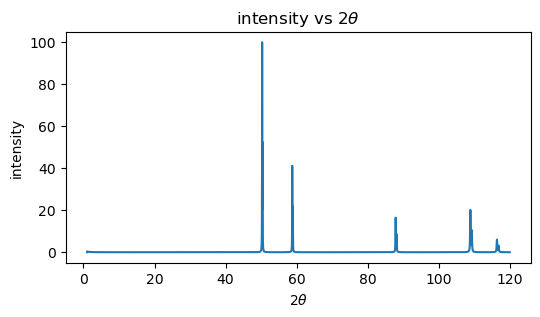

a: 3.139
Classification: face centered cubic


,2theta,intensity,d,hkl
0,50.29,100.00000,1.812146,111
1,58.76,41.13951,1.569508,200
2,87.87,16.47745,1.109763,220
3,108.90,20.12055,0.946401,311
4,116.38,6.04808,0.906095,222
5,116.83,3.17449,0.903900,222


In [80]:
process_spectrum('xrd_jupyter_data/AuB2.xy')


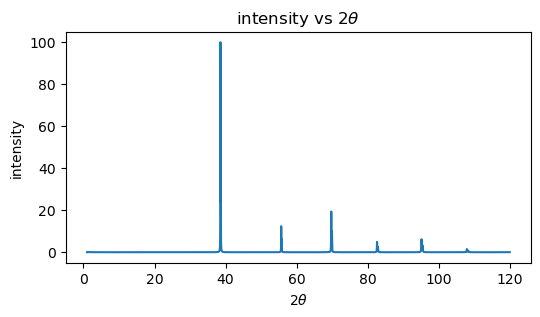

a: 2.333
Classification: simple cubic


,2theta,intensity,d,hkl
0,38.55,100.00000,2.332608,100
1,55.66,12.37520,1.649353,110
2,55.81,6.38289,1.645275,110
3,69.75,19.35729,1.346653,111
4,82.63,4.92853,1.166316,200
5,95.15,6.17045,1.043133,210
6,95.45,3.22817,1.040646,210


In [81]:
process_spectrum('xrd_jupyter_data/NbTa.xy')


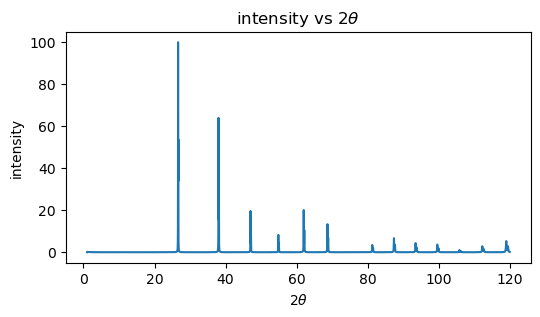

a: 3.343
Classification: simple cubic


,2theta,intensity,d,hkl
0,26.63,100.00000,3.343400,100
1,38.01,63.97598,2.364497,110
2,47.01,19.63319,1.930652,111
3,54.85,8.24286,1.671779,200
4,54.99,4.33906,1.667854,200
5,61.99,20.05835,1.495252,210
6,68.68,13.33781,1.365000,211
7,68.87,6.93285,1.361697,211
8,81.29,3.45592,1.182123,220
9,87.39,6.69659,1.114619,221


In [82]:
process_spectrum('xrd_jupyter_data/Po.xy')


### Question 4
`10 points`

- C2.1: Explain diffraction as a consequence of wave interference under geometric constraints
- C2.2: Use powder XRD data to determine lattice spacings and relate extracted structural parameters to underlying crystal structures

a) What feature of the physical crystal do the $2\theta$ values from our spectrum directly correspond to? What determines this feature?

b) In a powder XRD experiment, why do diffraction peaks appear at fixed values of $2\theta$ even though the crystallites are randomly oriented? Explain your answer in terms of Bragg's law and geometric averaging.

c) For one dataset, list the first three observed $(hkl)$ reflections. Using these indices, explain how you determined whether the lattice is simple cubic, FCC, or BCC. 

---


a) The 2 theta values correspond to the interplanar spacing. This feature is determined by the positions of the atoms and which planes can fit on them.

b) this happens because every single possible angle of mirror plane is roughly equally represented in the powder sample; this is determined by the points of constructive interference from Bragg's law averaged out over all orientations.

c) for the first spectrum we see 111, 200, 220. Note that in these indices they are either all even or all odd! this is the condition for the face-centered cubic lattice. 112 is systematically absent from this sequence because of symmetry rules for this lattice.


<br></br>

## Reflection
`10 points`

1. Throughout this lab, you encountered quantization in several different physical contexts: standing waves, slit diffraction, atomic planes, and powder XRD. Explain what these phenomena have in common. How does the requirement of phase matching contribute?

2. In this experiment, crystal structure information emerged from interference between scattered X-ray waves, even though individual atoms were never directly observed. Reflect on how macroscopic measurements (diffraction peaks) encode microscopic order (lattice geometry). What assumptions about the microscopic structure are essential for this connection to hold?

3. You used computational models to predict diffraction behavior and then compared those predictions to experimental data. How did writing and modifying your own code affect your understanding of XRD compared to treating it as a purely black-box technique? Which specific concepts, if any, were made clearer with code?

4. Was there anything you found particularly difficult about this lab? What background would have made you feel more confident?

---

1. In all of these cases, waves scatter and regions of constructive and destructive interference form based on the boundary conditions. There are only certain regions where the waves will line up just right, and it results in us being able to macroscopically observe micro-scale structure.

2. The macroscopic spectrum is on a scale we can usefully observe, and it is a function of the atomic coordinates. The function is simple, though working backwards and  separating all the different contributions may be complex. It is necessary that the atoms have periodic repeating structure and are arranged in a lattice for diffraction of this sort to be observed. (Note - we can actually do xrd on aperiodic liquids to get radial distribution functions! similar idea to powder XRD)

3. up to the student!

4. up to the student!
